# II. Modélisation : construction de la Baseline (Régression Logistique)

Ce notebook est dédié à la construction de notre modèle de référence. L'objectif est de poser un premier jalon de performance mathématique et financière. Ce modèle simple servira de point de comparaison pour mesurer l'apport de notre modèle optimisé (XGBoost).

### Import des librairies & fonctions

In [2]:
# Commandes de rechargement automatique des fichiers
%reload_ext autoreload
%autoreload 2

# Configuration de la racine du projet pour éviter le ModuleNotFoundError
import sys
from pathlib import Path

racine_projet = Path.cwd().parent
if str(racine_projet) not in sys.path:
    sys.path.append(str(racine_projet))
#print(f"Racine du projet ajoutée au sys.path : {racine_projet}")

# Packages de manipulation des tableaux et DataFrames
import pandas as pd

#package plotly pour la visualisation des données
import plotly.express as px

#package pour sauvegarde des modèles
import joblib

# Packages scikit-learn pour la modélisation
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# forcer l'affichage dans github des images Plotly interactifs
import plotly.io as pio
pio.renderers.default = "png"

#package des fonctions de preparation des donnees (../src/data_prep.py)
from src.data_prep import (
    load_data, 
    features_target_separation,
    get_column_types,
    data_preprocessing
)

#package des fonctions de train (../src/train.py)
from src.train import (
    separation_data_train_test, 
    entrainer_les_modeles, 
    entrainer_les_modeles
)

#package des fonctions de métriques (../src/metrics.py)
from src.metrics import (
    model_evaluation, 
    recall_and_precison_at_10,
    generate_metrics_report_baseline, 
    tracer_matrices_confusion,
    tracer_courbes_roc
)

In [3]:
#Configuration des options d'affichage de pandas
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)

## 1. Chargement du jeu de données et séparation train/test

In [5]:
# Chargement des données avec la focntion load_data_new de data_prep.py

df = load_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"La Dataframe df conient: {df.shape[0]} lignes et {df.shape[1]} colonnes ")


# Separation des variables explicatives (X) et de la variable cible (y)
X, y = features_target_separation(df, col_target='Churn', col_change_type='TotalCharges')
print(f"La Dataframe features X contient: {X.shape[0]} lignes et {X.shape[1]} colonnes ")
print(f"La target y contient: {y.shape} lignes\n")

# vérifier les données
cat_cols, num_cols, all_cols = get_column_types(X)
print(f"liste de toutes les colonnes: {all_cols}" )
print(f"liste des colonnes numériques: {num_cols}" )
print(f"liste des colonnes catégorielles: {cat_cols}" )

# Séparation en train et test avec stratification
X_train, X_test, y_train, y_test, id_test = separation_data_train_test(X, y)

print("\nDimensions des données d'entraînement :")
print(f"  - Variables explicatives (X_train) : {X_train.shape}")
print(f"  - Variable cible (y_train) : {y_train.shape}\n")

# Vérification de la stratification
print("Distribution de la variable cible :")
print(f"  - Train : {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"  - Test  : {y_test.value_counts(normalize=True).round(4).to_dict()}")


Nom du fichier : 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
La Dataframe df conient: 7043 lignes et 21 colonnes 
La Dataframe features X contient: 7043 lignes et 20 colonnes 
La target y contient: (7043,) lignes

liste de toutes les colonnes: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
liste des colonnes numériques: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
liste des colonnes catégorielles: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensions des données d'entraînement :
  - Variables explicativ

### 1.1. Analyse de la distribution de la variable cible (Déséquilibre des classes)

In [6]:
# Vérification du déséquilibre des classes
print(y_train.value_counts(normalize=True).round(3))

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


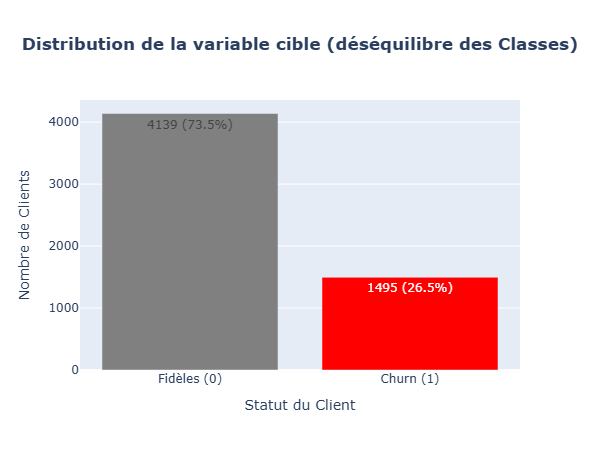

In [7]:

# Calcul des proportions
counts = y_train.value_counts()
proportions = y_train.value_counts(normalize=True) * 100

# Création du graphique en barres
fig = px.bar(
    x=['Fidèles (0)', 'Churn (1)'],
    y=counts.values,
    text=[f"{v} ({p:.1f}%)" for v, p in zip(counts.values, proportions.values)],
    title="<b>Distribution de la variable cible (déséquilibre des Classes)</b>",
    labels={'x': 'Statut du Client', 'y': 'Nombre de Clients'},
    color=['Fidèles (0)', 'Churn (1)'],
    color_discrete_map={'Fidèles (0)': 'gray', 'Churn (1)': 'red'} # rouge=Churn
)

# Mise en page
fig.update_traces(textposition='inside')
fig.update_layout(title_x=0.5, width=600, height=450, showlegend=False)
fig.write_image(f"../reports/figures/Distribution_variable_cible.png", scale=3)
fig.show()


Le graphique montre un déséquilibre modéré de classes : 
* **Classe (Churn=0)**: `73,5 %` des clients.
* **Classe (Churn=1)**: `26,54 %` des clients.

## 2. Préparation des données (preprocessing) et entraînement

### 2.1 Prétraitement des données

* **`Variables numériques`**:  
Imputation par la médiane (SimpleImputer) + Standardisation (StandardScaler).
* **`Variables catégorielles`**:  
Imputation par une valeur fixe et unique "missing" (SimpleImputer)+ Encodage (OneHotEncoder avec handle_unknown='ignore'). 



In [8]:
#Preprosessing des données

preprocesseur = data_preprocessing(X_train)
#Affichage pipeline
from sklearn import set_config
set_config(display='diagram')

#Affichage du preprocesseur
preprocesseur

Colonnes numériques : Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Colonnes catégorielles : Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('var_num', ...), ('var_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

### 2.2. Définition des modèles et entraînement

Nous allons utiliser deux modèles, les entrainer et les comparer :  
1. **DummyClassifier**  
Ce modèle nous servira de point de comparaison minimal.  Il applique une stratégie uniforme (prédiction systématique de la classe majoritaire). Tout modèle prédictif développé par la suite devra obligatoirement faire mieux.  
2. **Régression logistique**  
La Régression Logistique est notre baseline. C'est le modèle standard, simple, linéaire et très rapide.
ll va nous permettre d'établir un premier score de performance pointueux (ROC-AUC, Précision, Recall) avant d'introduire des algorithmes non linéaires plus complexes comme le XGBoost.

In [9]:

set_seed = 1204

# Liste des modèles à entraîner
models = {
    #DummyClassifier pour générer des prédictions de façon aléatoire
    "DummyClassifier":
    DummyClassifier(
        strategy='stratified',
        random_state=set_seed
    ),
    #Régression logistique
    "LogisticRegression":
        LogisticRegression(
        class_weight='balanced',
        random_state=set_seed, 
        max_iter=1000)
}
#Initialisation du modele baseline
model_baseline=None
metrics_comparaison = {}
# Bouclez sur chacun des modèles
for model_name, model in models.items():
    print(60*"=")
    print(f"{model_name}")
    print(60*"=")

    # Entraînez le modèle
    fit_m = entrainer_les_modeles(preprocesseur, model, X_train, y_train)

    #definir le modele "LogisticRegression" comme modele de base
    if(model_name=="LogisticRegression"):
        model_baseline=fit_m

    
    # Calculez les AUC du train et du test
    model_evaluation(fit_m, X_train, y_train, X_test, y_test)


DummyClassifier
AUC : 0.4958 (train) 0.4932 (test)
L'accuracy : 60.6319 % (train)
L'accuracy : 60.5394 % (test)

Rapport de classification (test) :

              precision    recall  f1-score   support

   Churn (0)       0.73      0.73      0.73      1035
   Churn (1)       0.26      0.25      0.25       374

    accuracy                           0.61      1409
   macro avg       0.49      0.49      0.49      1409
weighted avg       0.60      0.61      0.61      1409

LogisticRegression
AUC : 0.8492 (train) 0.8413 (test)
L'accuracy : 75.3106 % (train)
L'accuracy : 73.8112 % (test)

Rapport de classification (test) :

              precision    recall  f1-score   support

   Churn (0)       0.90      0.72      0.80      1035
   Churn (1)       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 2.3 Interprétation des rapports de classification et validation des baselines

L'analyse comparative entre notre modèle de référence (`DummyClassifier`) et notre premier modèle prédictif (`LogisticRegression`) apporte des enseignements majeurs pour la stratégie à suivre par la suite :

* **Validation de la supériorité de la Régression Logistique**  
  Le `DummyClassifier` affiche une précision de **0.26** sur la classe Churn, ce qui correspond exactement exactement à la proportion réelle de churners dans notre échantillon de test (26 %). En passant à la Régression Logistique, cette précision atteint **0.50**. Le modèle permet donc de **doubler l'efficacité du ciblage** par rapport au hasard : le taux de succès passe de 26 % à 52 %, soit environ une alerte correcte sur deux. 

* **Une sensibilité métier élevée (Rappel = 0.78)**  
  La Régression Logistique identifie **78 % de l'ensemble des clients à risque** du jeu de test. Cette sensibilité élevée est un atout fort d'un point de vue business, car elle minimise le risque de rater un client sur le départ (Faux Négatif).

* **Pouvoir séparateur et robustesse (AUC)**  
  Le score ROC-AUC s'élève à **0,8492** sur le jeu d'entraînement. Cela signifie que dans près de **85 %** des cas, le modèle attribue une probabilité de départ plus élevée à un client à risque qu'à un client stable. De plus, l'écart infime **(0,0079)** avec le jeu de test (0,8413) démontre la parfaite stabilité du modèle et l'**absence de sur-apprentissage**.


## 3. Évaluation approfondie et métriques complémentaires

### 3.1 Analyse fine des erreurs (Matrice de confusion)

vn: 747, fp: 288

fn: 81, vp: 293

Graphique sauvegardé sous : ../reports/figures/matrice_confusion_Regression logistique.png


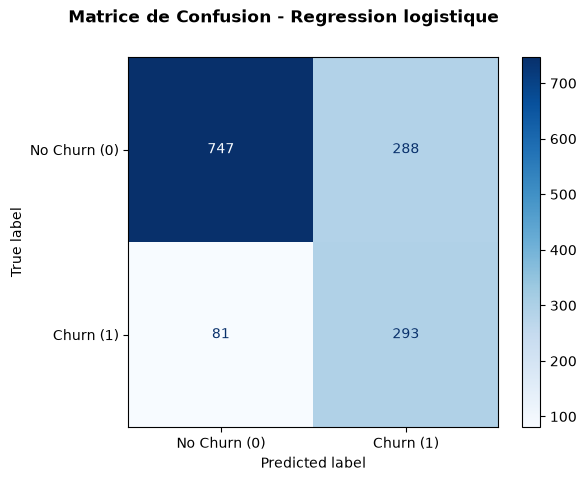

In [10]:
y_pred_baseline = model_baseline.predict(X_test)
tracer_matrices_confusion(y_test, y_pred_baseline, "Regression logistique")

- la matrice montre beaucoup plus de VN et VP que de FP et FN, le modèle est globalement bon.
- Les FN (288) sont élevé ce qui confirme qu'il faut augmenter la précision.


La visualisation de la matrice de confusion permet de confronter directement les prédictions du modèle aux données réelles, en mettant en lumière la nature exacte des erreurs commises :

* **Un bon comportement global sur les volumes principaux :**
  Pour la Régression Logistique, la diagonale principale affiche une forte concentration de Vrais Négatifs (VN=747) et de Vrais Positifs (VP = 293). Le modèle démontre ainsi une capacité globale satisfaisante à catégoriser correctement la majorité des clients.

* **L'impact du volume de Faux Positifs (FP = 288) :**
  L'analyse détaillée révèle un volume important de 288 Faux Positifs (en haut à droite). Ces cas représentent des clients stables que le modèle a classés à tort comme "à risque de répart". C'est ce volume d'alertes erronées qui explique mathématiquement pourquoi la précision stagne à **0.50**.

* **La maîtrise des Faux Négatifs (FN = 82) :**
  À l'inverse, le modèle ne compte que 82 Faux Négatifs (en bas à gauche). Ce faible nombre confirme l'excellent score de **Rappel (0.78)**. La Régression Logistique remplit ici son rôle protecteur en interceptant la grande majorité des départs.

Ce bilan pose parfaitement le compromis actuel : un excellent Rappel (seulement 82 clients ratés) payé au prix d'une précision moyenne (288 fausses alertes). Le passage à un modèle non linéaire plus complexe (**XGBoost**)  permettera peut être de diminuer ce volume de 288 Faux Positifs pour maximiser la précision.




### 3.2 Évaluation du pouvoir séparateur (Courbes ROC)

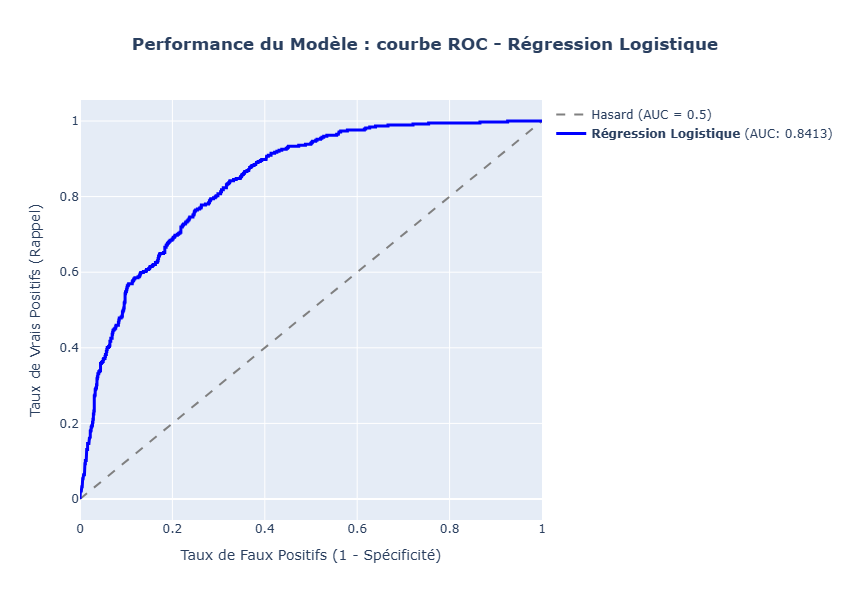

In [11]:
#Calcul des probabilités de la classe 1
y_test_baseline_proba_1 = model_baseline.predict_proba(X_test)[:,1]

#tracer la courve roc
tracer_courbes_roc(y_test, y_test_baseline_proba_1, "Régression Logistique")

La courbe ROC et l'indice AUC associé permettent de mesurer la capacité de nos modèles à distinguer les deux classes (Chur=1) et (Churn=0) indépendamment de tout choix de seuil de décision :

* **Validation du pouvoir prédictif par rapport au hasard :**
  La courbe met en évidence l'écart massif entre la courbe de la Régression Logistique (AUC test = **0.8413**) et la diagonale de référence représentant un choix purement aléatoire (AUC $\approx$ **0.50**, matérialisé par le DummyClassifier).  

* **Interprétation probabiliste de l'AUC :**
  Avec un score d'AUC de **0,8413** sur l'échantillon de test, le modèle offre une excellente séparabilité des classes. Concrètement, si l'on sélectionne de manière aléatoire un client qui va réellement résilier et un client stable, la Régression Logistique attribuera une probabilité de départ plus élevée au premier dans plus de 84 % des cas.

La trajectoire de la courbe s'élève rapidement vers le coin supérieur gauche, ce qui confirme la robustesse de la Régression Logistique comme première fondation de notre système de scoring. Cette performance globale servira de point de comparaison direct pour évaluer, dans le Notebook III, si l'architecture non linéaire du XGBoost permettra d'aboutir à de meilleurs résultats.


### 3.3 Évaluation orientée business (simulation du top ciblage @10%)

Afin de mesurer la performance du modèle sur les clients les plus à risque, nous calculons la précision et le recall à 10%.<br>
Formules appliquées sur notre échantillon de test :<br><br>
$ \text{Recall@10\%} = \frac{\text{Nombre de vrais positifs dans le top 10\%}}{\text{Nombre total de vrais positifs dans tout l'échantillon de test}} $<br>

$ \text{Precision@10\%} = \frac{\text{Nombre de vrais positifs dans le top 10\%}}{\text{Nombre total d'individus dans le top 10\%}} $.

In [12]:
recall_at_10, precision_at_10=recall_and_precison_at_10(y_test_baseline_proba_1, y_test)
print(f"Recall@10%: {recall_at_10 * 100:.2f}% \tPrecision@10%: {precision_at_10 * 100:.2f}%")

Recall@10%: 28.34% 	Precision@10%: 75.71%


Au-delà des indicateurs statistiques globaux, l'évaluation finale d'un modèle de churn doit mesurer son efficacité opérationnelle. Dans un scénario réel, les équipes marketing disposent souvent de ressources limitées (coûts des offres de rétention, capacité d'appels des conseillers). Nous simulons ici une contrainte forte : l'entreprise décide de ne cibler que les **10 % de clients les plus à risque** selon les probabilités de notre Régression Logistique.

* **Une excellente précision (Precision@10% = 75.71 %) :**
  Ce score signifie que, parmi les 10 % de clients identifiés comme les plus risqués par le modèle, **75.71 % sont effectivement des clients à risque**. Plus concrètement, sur les 141 clients qui composent ce premier décile, près de 106 sont de vrais positifs. C'est un excellent signal pour le ciblage : le modèle classe idéalement les profils les plus dangereux au sommet de la liste, garantissant une efficacité maximale si l'on ne peut contacter qu'un petit segment de clients.

* **Une couverture partielle (Recall@10% = 28.34 %) :**
  Ce résultat indique que ce top 10 % permet d'intercepter à lui seul **28.34 % de l'ensemble des futures résiliations réelles** de l'échantillon de test. À l'inverse, environ 71.66 % des résiliations se situeront en dehors de cette zone prioritaire. Le modèle excelle donc à prioriser l'urgence, mais ce ciblage restreint ne capture pour l'instant qu'un peu plus d'un quart des départs totaux.

Cette simulation valide le très bon potentiel du modèle pour des campagnes de relance prioritaires, en concentrant une grande densité de clients sur le départ sur un volume ciblé. Néanmoins, il reste une marge importante pour augmenter la couverture globale des clients à risque (le rappel).



### 4. Sauvegarde des modèles

In [13]:

# Fichier de sortie : baseline_logistic_regression.joblib
joblib.dump(model_baseline, "../models/baseline.joblib")

# Génération du fichier Scoring CSV demandé
scoring_df = pd.DataFrame({
    'customerID': id_test,
    'proba_churn': model_baseline.predict_proba(X_test)[:, 1],
    'label_pred': model_baseline.predict(X_test)
})
scoring_df.to_csv("../reports/scoring_outputs_baseline.csv", index=False)

print(scoring_df['label_pred'].value_counts())
print("Modèle sauvegardé et fichier CSV de scoring généré avec succès.")



label_pred
0    828
1    581
Name: count, dtype: int64
Modèle sauvegardé et fichier CSV de scoring généré avec succès.


### 5. Géneration du rapport

In [14]:
y_test_pred = model_baseline.predict(X_test)
generate_metrics_report_baseline(y_test, y_test_pred)

Metrics.py est exécuté depuis le dossier :  c:\Users\ReMarkt\Documents\Scoring-de-churn-client\notebooks
Chemin du dossier src : c:\Users\ReMarkt\Documents\Scoring-de-churn-client\src
Chemin du rapport : c:\Users\ReMarkt\Documents\Scoring-de-churn-client\reports\rapport_metriques_baseline.md
-> Fichier 'rapport_metriques_baseline.md' généré avec succès.


### Conclusion et perspectives

Dans ce notebook nous avons posé des fondations méthodologiques et analytiques solides pour notre projet de prédiction du churn :

1. **Validation de la démarche prédictive :** l'évaluation de notre premier modèle statistique (`LogisticRegression`) a démontré une supériorité incontestable face à notre référence aléatoire (`DummyClassifier`). Avec un score ROC-AUC robuste de **0,8413** et une absence totale de sur-apprentissage (overfitting), le modèle extrait des signaux comportementaux pertinents et stables.
2. **Un arbitrage orienté vers la sécurité (Seuil 50 %) :** au seuil par défaut, la Régression Logistique offre un excellent **Rappel de 78 %** (seulement 82 clients à risque ratés sur 374), sécurisant ainsi la détection de la majorité des départs, au prix d'une **Précision modérée de 50 %** (288 fausses alertes).
3. **Une excellente efficacité du Top Ciblage :** la simulation métier prouve la capacité du modèle à prioriser l'urgence. En n'analysant que les **10 % de profils les plus à risque**, le modèle isole une forte densité de vrais positifs (**Précision@10% de 75,71 %**), permettant d'intercepter d'un coup **28,34 %** de l'attrition totale.

**`Perspectives pour le Notebook III :`**
Bien que la Régression Logistique pose des bases saines, ses frontières de décision linéaires limitent sa capacité à capter des interactions complexes et non linéaires entre les variables. L'étape suivante consistera à passer à l'échelle supérieure avec un algorithme de Gradient Boosting de pointe : **XGBoost**. 

L'objectif du prochain Notebook sera d'utiliser le fine-tuning (optimisation fine des hyperparamètres) pour observer si ces structures d'arbres avancées parviennent à diminuer le nombre de faux positifs (288) et à maximiser encore davantage la rentabilité financière.